In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Embedding
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample
import optuna

Verinin yüklenmesi

In [2]:
df = pd.read_csv('missense_mutations.csv')
df = df[df['ClinSigSimple'].isin([0, 1])].copy()
df

,#AlleleID,Type,Name,GeneID,GeneSymbol,HGNC_ID,ClinicalSignificance,ClinSigSimple,LastEvaluated,RS# (dbSNP),...,AlternateAlleleVCF,SomaticClinicalImpact,SomaticClinicalImpactLastEvaluated,ReviewStatusClinicalImpact,Oncogenicity,OncogenicityLastEvaluated,ReviewStatusOncogenicity,SCVsForAggregateGermlineClassification,SCVsForAggregateSomaticClinicalImpact,SCVsForAggregateOncogenicityClassification
0,24368,single nucleotide variant,NM_000059.4(BRCA2):c.1114A>C (p.Asn372His),675,BRCA2,HGNC:1101,Benign,0,"Jan 12, 2015",144848,...,C,-,-,-,-,-,-,SCV000245002,-,-
1,24368,single nucleotide variant,NM_000059.4(BRCA2):c.1114A>C (p.Asn372His),675,BRCA2,HGNC:1101,Benign,0,"Jan 12, 2015",144848,...,C,-,-,-,-,-,-,SCV000245002,-,-
2,24379,single nucleotide variant,NM_000059.4(BRCA2):c.8165C>G (p.Thr2722Arg),675,BRCA2,HGNC:1101,Pathogenic,1,"Aug 10, 2015",80359062,...,G,-,-,-,-,-,-,SCV000244480,-,-
3,24379,single nucleotide variant,NM_000059.4(BRCA2):c.8165C>G (p.Thr2722Arg),675,BRCA2,HGNC:1101,Pathogenic,1,"Aug 10, 2015",80359062,...,G,-,-,-,-,-,-,SCV000244480,-,-
4,24384,single nucleotide variant,NM_000059.4(BRCA2):c.7529T>C (p.Leu2510Pro),675,BRCA2,HGNC:1101,Pathogenic/Likely pathogenic,1,"Jul 09, 2024",80358979,...,C,-,-,-,-,-,-,SCV000567107|SCV000607817|SCV001478276|SCV0015...,-,-
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11229,4185255,single nucleotide variant,NM_000059.4(BRCA2):c.8754G>C (p.Glu2918Asp),675,BRCA2,HGNC:1101,Likely pathogenic,1,"Jun 12, 2025",-1,...,C,-,-,-,-,-,-,SCV006298678,-,-
11230,4198803,single nucleotide variant,NM_000059.4(BRCA2):c.1307A>G (p.Lys436Arg),675,BRCA2,HGNC:1101,Uncertain significance,0,-,-1,...,G,-,-,-,-,-,-,SCV006333499,-,-
11231,4198803,single nucleotide variant,NM_000059.4(BRCA2):c.1307A>G (p.Lys436Arg),675,BRCA2,HGNC:1101,Uncertain significance,0,-,-1,...,G,-,-,-,-,-,-,SCV006333499,-,-
11232,4391609,single nucleotide variant,NM_007294.4(BRCA1):c.298G>C (p.Glu100Gln),672,BRCA1,HGNC:1100,Uncertain significance,0,"Jul 31, 2025",-1,...,G,-,-,-,-,-,-,SCV006554521,-,-


In [3]:
print(df['ClinSigSimple'].value_counts(normalize=True))

ClinSigSimple
0    0.907679
1    0.092321
Name: proportion, dtype: float64


Veri dağılımının dengesiz olması ve 0 olan sınıfın ağır basması sebebi ile sınıfları eşitleme işlemine gidilmiştir.

In [4]:
df_majority = df[df.ClinSigSimple == 0] # Benign
df_minority = df[df.ClinSigSimple == 1] # Pathogenic

In [5]:
df_majority_downsampled = resample(df_majority, 
                                 replace=False,    
                                 n_samples=len(df_minority), # 832'ye düşür
                                 random_state=42)

In [6]:
df_balanced = pd.concat([df_majority_downsampled, df_minority])
print(f"Eşitlenmiş Veri Dağılımı: {df_balanced['ClinSigSimple'].value_counts().to_dict()}")

Eşitlenmiş Veri Dağılımı: {0: 832, 1: 832}


Özelliklerin çıkartılması

In [7]:
features = ['GeneSymbol', 'Chromosome', 'Start', 'Stop', 'ReferenceAlleleVCF', 'AlternateAlleleVCF']
X = df_balanced[features].copy()
y = df_balanced['ClinSigSimple'].values

Kategorik verilerin sayıya çevrilmesi 

In [8]:
le = LabelEncoder()
for col in ['GeneSymbol', 'ReferenceAlleleVCF', 'AlternateAlleleVCF']:
    X[col] = le.fit_transform(X[col].astype(str))

Ölçekleme

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [10]:
X_reshaped = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))

Modelin bölünmesi eğitim/test

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X_reshaped, y, test_size=0.2, random_state=42, stratify=y)

Modelin oluşturulması

In [12]:
model = Sequential([
    LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=True),
    Dropout(0.3),
    LSTM(32),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid') # Çıkış katmanı (0 veya 1)
])

C:\Users\emirh\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [13]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

Modelin derlenmesi

In [14]:
history = model.fit(
    X_train, y_train, 
    epochs=50, 
    batch_size=32, 
    validation_split=0.1,
    verbose=1
)

Epoch 1/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.6094 - loss: 0.6888 - val_accuracy: 0.6866 - val_loss: 0.6654
Epoch 2/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6290 - loss: 0.6696 - val_accuracy: 0.6866 - val_loss: 0.6315
Epoch 3/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6009 - loss: 0.6707 - val_accuracy: 0.6866 - val_loss: 0.6131
Epoch 4/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6310 - loss: 0.6502 - val_accuracy: 0.6866 - val_loss: 0.6057
Epoch 5/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6474 - loss: 0.6369 - val_accuracy: 0.6866 - val_loss: 0.5990
Epoch 6/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6147 - loss: 0.6437 - val_accuracy: 0.6866 - val_loss: 0.5945
Epoch 7/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6156 - loss: 0.6448 - val_accuracy: 0.6866 - val_loss: 0.5886
Epoch 8/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6041 - loss: 0.6577 - val_accuracy: 0.6567 - val_loss

Test edilmesi

In [15]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


In [16]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.62      0.71      0.66       167
           1       0.66      0.55      0.60       166

    accuracy                           0.63       333
   macro avg       0.64      0.63      0.63       333
weighted avg       0.64      0.63      0.63       333



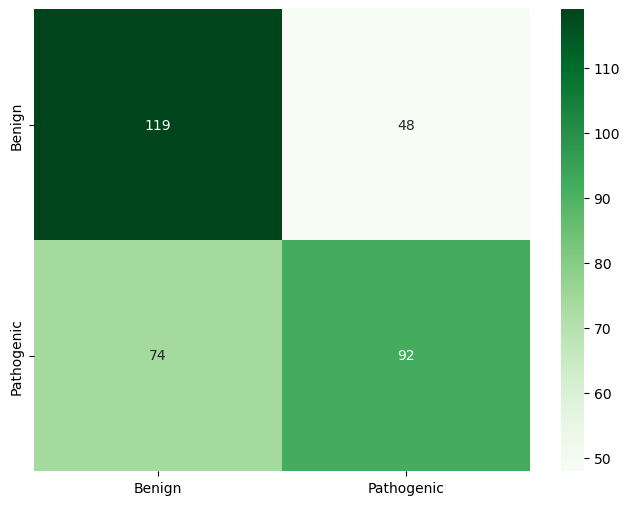

In [17]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Benign', 'Pathogenic'], yticklabels=['Benign', 'Pathogenic'])
plt.show()

In [18]:
acc = accuracy_score(y_test, y_pred)
acc

0.6336336336336337

## Optuna Kullanımı

In [19]:
def objective(trial):
    # 1. Hiperparametre 
    n_layers = trial.suggest_int('n_layers', 1, 3)
    lr = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])
    
    model = Sequential()
    
    # 2. Dinamik LSTM Mimarisi 
    for i in range(n_layers):
        units = trial.suggest_int(f'lstm_units_l{i}', 16, 128, step=16)
        
        is_last_lstm = (i == n_layers - 1)
        
        if i == 0:
            model.add(LSTM(units, return_sequences=not is_last_lstm, 
                           input_shape=(X_train.shape[1], X_train.shape[2])))
        else:
            model.add(LSTM(units, return_sequences=not is_last_lstm))
        
        # Dropout 
        model.add(Dropout(trial.suggest_float(f'dropout_l{i}', 0.1, 0.4)))
    
    # Çıkış Katmanı 
    model.add(Dense(1, activation='sigmoid'))

    # 3. Derleme
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    # 4. Eğitim
    history = model.fit(
        X_train, y_train,
        epochs=20, 
        batch_size=batch_size,
        validation_split=0.2, 
        verbose=0
    )

    # 5. Skor döndür 
    val_acc = history.history['val_accuracy'][-1]
    return val_acc

In [20]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

[I 2026-03-22 12:02:54,023] A new study created in memory with name: no-name-f24adc75-996d-4a93-b53d-30e10a75c866
C:\Users\emirh\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
[I 2026-03-22 12:02:57,393] Trial 0 finished with value: 0.7003745436668396 and parameters: {'n_layers': 1, 'learning_rate': 0.00010329163034411857, 'batch_size': 64, 'lstm_units_l0': 16, 'dropout_l0': 0.2658340811380536}. Best is trial 0 with value: 0.7003745436668396.
[I 2026-03-22 12:03:03,450] Trial 1 finished with value: 0.6779026389122009 and parameters: {'n_layers': 3, 'learning_rate': 0.0036878230377895126, 'batch_size': 64, 'lstm_units_l0': 48, 'dropout_l0': 0.30126084875414555, 'lstm_units_l1': 80, 'dropout_l1': 0.21953822783517582, 'lstm_units_l2': 112, 'dropout_l2': 0.2059008114

In [21]:
print(f"En İyi Skor: {study.best_value}")
print("En İyi Parametreler:", study.best_params)

En İyi Skor: 0.7003745436668396
En İyi Parametreler: {'n_layers': 1, 'learning_rate': 0.00010329163034411857, 'batch_size': 64, 'lstm_units_l0': 16, 'dropout_l0': 0.2658340811380536}
